# Microsoft Security Incident Prediction - Modeling

Predicts `IncidentGrade` (TruePositive/FalsePositive/BenignPositive) using the GUIDE
dataset. Evaluated with macro F1 on a strict OrgId-held-out split (model never sees an
organization during training that it's evaluated on).

## Setup

In [1]:
# # To actually delete everything in /kaggle/working (careful — this is permanent for this session)
# for f in os.listdir('/kaggle/working'):
#     path = os.path.join('/kaggle/working', f)
#     if os.path.isfile(path):
#         os.remove(path)
#     else:
#         shutil.rmtree(path)
# print("Cleared /kaggle/working/")
# import os, shutil

# SRC = '/kaggle/input/notebooks/harshparsana03/ml-model-v0' 
# DST = '/kaggle/working'

# if os.path.exists(SRC):
#     shutil.copytree(SRC, DST, dirs_exist_ok=True)
#     print(f"Copied everything from {SRC} to {DST}")
# else:
#     print(f"SRC not found: {SRC} — check the folder name above")

SRC not found: /kaggle/input/notebooks/harshparsana03/ml-model-v0 — check the folder name above


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os
import joblib
from collections import Counter

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, KFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay, make_scorer
)
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)

SAVE_DIR = '/kaggle/working/models'
os.makedirs(SAVE_DIR, exist_ok=True)

def checkpoint():
    train_full.to_parquet('/kaggle/working/checkpoint_train.parquet')
    test_df.to_parquet('/kaggle/working/checkpoint_test.parquet')
    joblib.dump({
        'feature_cols_v4': globals().get('feature_cols_v4'),
        'le': globals().get('le'),
        'target_col': globals().get('target_col'),
        'true_positive_class': globals().get('true_positive_class'),
    }, '/kaggle/working/checkpoint_meta.pkl')
    print("Checkpoint saved.")

def restore_checkpoint():
    global train_full, test_df, feature_cols_v4, le, target_col, true_positive_class
    train_full = pd.read_parquet('/kaggle/working/checkpoint_train.parquet')
    test_df = pd.read_parquet('/kaggle/working/checkpoint_test.parquet')
    meta = joblib.load('/kaggle/working/checkpoint_meta.pkl')
    feature_cols_v4 = meta['feature_cols_v4']
    le = meta['le']
    target_col = meta['target_col']
    true_positive_class = meta['true_positive_class']
    print("Restored data + metadata.")

def save_and_release(model, name):
    path = f'{SAVE_DIR}/{name}.json'
    model.save_model(path)
    del model
    gc.collect()
    print(f"Saved '{name}' to {path} and released it from memory.")

def load_model(name):
    m = XGBClassifier()
    m.load_model(f'{SAVE_DIR}/{name}.json')
    return m

def downcast_dtypes(df):
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
    return df

def show_report(y_true, y_pred, label_encoder, title):
    """Prints classification_report + plots a confusion matrix. Call this after
    every F1 score so results are always inspected at the per-class level too."""
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.show()

categorical_cols = [
    'Category', 'EntityType', 'ActionGrouped', 'ActionGranular',
    'EvidenceRole', 'ResourceType', 'Roles', 'AntispamDirection',
    'SuspicionLevel', 'LastVerdict', 'MitreTechniques', 'ThreatFamily',
    'OSFamily', 'OSVersion', 'CountryCode', 'State', 'City',
]

## Data Load & IncidentId Sanity Check

Standalone check, run once before the main pipeline: confirms `IncidentId` alone
carries no cross-org meaning (it's a per-org-recycled counter), which is *why*
every split/groupby in this notebook uses the composite key `(OrgId, IncidentId)`
and never raw `IncidentId`. Uses its own local `sanity_df` - unrelated to the
`train_full`/`test_df` built by the pipeline below.

In [2]:
import pandas as pd
sanity_df = pd.read_csv('/kaggle/input/notebooks/harshparsana03/security-incident/GUIDE_Train_clean_no_conversion.csv')
# 1. Is IncidentId globally unique, or does it repeat across orgs?
id_to_orgs = sanity_df.groupby('IncidentId')['OrgId'].nunique()
print("IncidentId values that appear under >1 OrgId:", (id_to_orgs > 1).sum())
print("Total unique IncidentId values:", id_to_orgs.shape[0])
print("Total unique (OrgId, IncidentId) pairs:", sanity_df.groupby(['OrgId','IncidentId']).ngroups)

# 2. For IncidentId values that DO repeat across orgs, are they similar in structure?
repeated_ids = id_to_orgs[id_to_orgs > 1].index

sample_id = repeated_ids[0]  # pick one to inspect
subset = sanity_df[sanity_df['IncidentId'] == sample_id]

print(f"\nExample: IncidentId={sample_id} appears under {subset['OrgId'].nunique()} different orgs")
print(subset.groupby('OrgId').agg(
    n_alerts=('AlertTitle', 'size'),
    grade=('IncidentGrade', lambda x: x.mode()[0]),  # majority label per org
    top_category=('Category', lambda x: x.mode()[0]),
))

# 3. Systematically: for repeated IncidentId values, does IncidentGrade agree across orgs?
grade_agreement = sanity_df[sanity_df['IncidentId'].isin(repeated_ids)].groupby('IncidentId')['IncidentGrade'].apply(
    lambda x: x.nunique() == 1  # True if all orgs sharing this ID agree on the label
)
print(f"\nOf {len(grade_agreement)} IncidentId values shared across multiple orgs:")
print(f"  {grade_agreement.sum()} have identical IncidentGrade across all orgs ({grade_agreement.mean()*100:.1f}%)")
print(f"  {(~grade_agreement).sum()} have conflicting IncidentGrade across orgs")

IncidentId values that appear under >1 OrgId: 131288
Total unique IncidentId values: 466151
Total unique (OrgId, IncidentId) pairs: 730778

Example: IncidentId=2 appears under 2 different orgs
       n_alerts           grade   top_category
OrgId                                         
42        20512  BenignPositive        Malware
392          13    TruePositive  InitialAccess

Of 131288 IncidentId values shared across multiple orgs:
  34464 have identical IncidentGrade across all orgs (26.3%)
  96824 have conflicting IncidentGrade across orgs


In [3]:
del sanity_df
import gc; gc.collect()

0

## Controlled Comparison - Sentinel-NaN vs. No-Conversion Cleaning

Two cleaned files exist, differing only in whether placeholder "not
applicable" text values got converted to NaN or left as distinct categories. Testing
both, same session, same code, only the file path differs, eliminates confounds from
earlier separate-session comparisons (split ordering drift, implementation drift).

Continuing with the sentinel-NaN version for pipeline continuity regardless of which
wins this run - the two have consistently scored within noise-level of each other.

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [23:06:56] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Sentinel -> NaN macro F1: 0.4095
                precision    recall  f1-score   support

BenignPositive       0.54      0.77      0.63    832383
 FalsePositive       0.32      0.23      0.27    369923
  TruePositive       0.51      0.24      0.33    502141

      accuracy                           0.50   1704447
     macro avg       0.46      0.41      0.41   1704447
  weighted avg       0.48      0.50      0.46   1704447



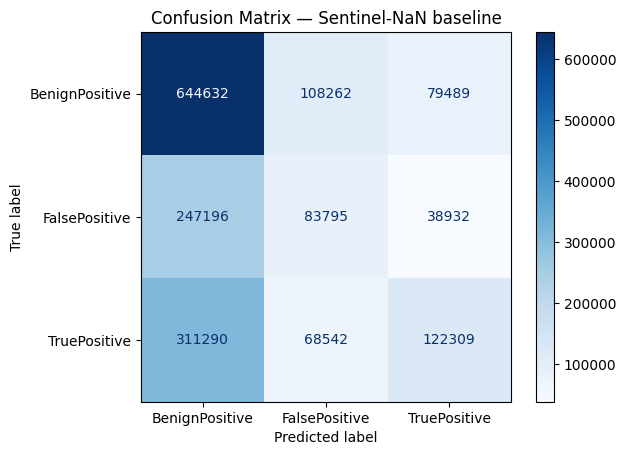

In [4]:
df_s = pd.read_csv('/kaggle/input/notebooks/harshparsana03/categorical-data-analysis/GUIDE_Train_post_cat_eda.csv')
df_s = df_s[df_s['IncidentGrade'].notna()].copy()

categorical_cols = [
    'Category', 'EntityType', 'ActionGrouped', 'ActionGranular',
    'EvidenceRole', 'ResourceType', 'Roles', 'AntispamDirection',
    'SuspicionLevel', 'LastVerdict', 'MitreTechniques', 'ThreatFamily',
    'OSFamily', 'OSVersion', 'CountryCode', 'State', 'City',
]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_s, groups=df_s['OrgId']))
train_s = df_s.iloc[train_idx].copy()
test_s = df_s.iloc[test_idx].copy()

le_s = LabelEncoder()
le_s.fit(train_s['IncidentGrade'])
train_s['IncidentGrade'] = le_s.transform(train_s['IncidentGrade'])
test_s['IncidentGrade'] = le_s.transform(test_s['IncidentGrade'])

for col in categorical_cols:
    train_s[col] = train_s[col].astype('category')
    test_s[col] = test_s[col].astype('category').cat.set_categories(train_s[col].cat.categories)

feature_cols_s = [c for c in train_s.columns if c not in ['IncidentGrade', 'OrgId', 'IncidentId', 'Timestamp']]
X_train_s, y_train_s = train_s[feature_cols_s], train_s['IncidentGrade']
X_test_s, y_test_s = test_s[feature_cols_s], test_s['IncidentGrade']

model_s = XGBClassifier(enable_categorical=True, tree_method='hist', device='cuda',
                         eval_metric='mlogloss', random_state=42)
model_s.fit(X_train_s, y_train_s)
y_pred_s = model_s.predict(X_test_s)

f1_s = f1_score(y_test_s, y_pred_s, average='macro')
print(f"Sentinel -> NaN macro F1: {f1_s:.4f}")
show_report(y_test_s, y_pred_s, le_s, 'Confusion Matrix — Sentinel-NaN baseline')

No conversion macro F1: 0.4138
                precision    recall  f1-score   support

BenignPositive       0.54      0.78      0.64    832383
 FalsePositive       0.33      0.25      0.28    369923
  TruePositive       0.51      0.23      0.32    502141

      accuracy                           0.50   1704447
     macro avg       0.46      0.42      0.41   1704447
  weighted avg       0.49      0.50      0.47   1704447



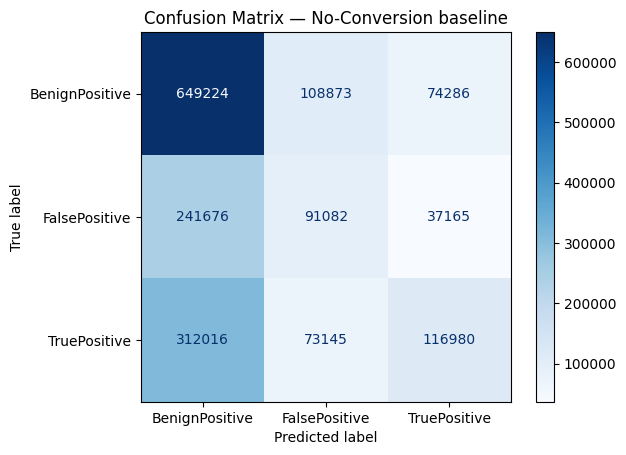

In [5]:
# Reconstructed: mirrors the sentinel-NaN cell above, on the no-conversion file.
# (This cell was missing from the original notebook — cells below reference
# f1_nc/df_nc/etc., so it must have existed in a prior session and been lost.)
df_nc = pd.read_csv('/kaggle/input/notebooks/harshparsana03/security-incident/GUIDE_Train_clean_no_conversion.csv')
df_nc = df_nc[df_nc['IncidentGrade'].notna()].copy()

gss_nc = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_nc, test_idx_nc = next(gss_nc.split(df_nc, groups=df_nc['OrgId']))
train_nc = df_nc.iloc[train_idx_nc].copy()
test_nc = df_nc.iloc[test_idx_nc].copy()

le_nc = LabelEncoder()
le_nc.fit(train_nc['IncidentGrade'])
train_nc['IncidentGrade'] = le_nc.transform(train_nc['IncidentGrade'])
test_nc['IncidentGrade'] = le_nc.transform(test_nc['IncidentGrade'])

for col in categorical_cols:
    train_nc[col] = train_nc[col].astype('category')
    test_nc[col] = test_nc[col].astype('category').cat.set_categories(train_nc[col].cat.categories)

feature_cols_nc = [c for c in train_nc.columns if c not in ['IncidentGrade', 'OrgId', 'IncidentId', 'Timestamp']]
X_train_nc, y_train_nc = train_nc[feature_cols_nc], train_nc['IncidentGrade']
X_test_nc, y_test_nc = test_nc[feature_cols_nc], test_nc['IncidentGrade']

model_nc = XGBClassifier(enable_categorical=True, tree_method='hist', device='cuda',
                          eval_metric='mlogloss', random_state=42)
model_nc.fit(X_train_nc, y_train_nc)
y_pred_nc = model_nc.predict(X_test_nc)

f1_nc = f1_score(y_test_nc, y_pred_nc, average='macro')
print(f"No conversion macro F1: {f1_nc:.4f}")
show_report(y_test_nc, y_pred_nc, le_nc, 'Confusion Matrix — No-Conversion baseline')

In [6]:
print(f"Sentinel -> NaN:  {f1_s:.4f}")
print(f"No conversion:    {f1_nc:.4f}")

Sentinel -> NaN:  0.4095
No conversion:    0.4138


In [7]:
import gc

# del df_s, train_s, test_s, X_train_s, X_test_s, model_s, y_pred_s
# gc.collect()

del df_nc, train_nc, test_nc, X_train_nc, X_test_nc, model_nc, y_pred_nc
gc.collect()

9770

## Target Setup

In [8]:
train_full = train_s
test_df = test_s
le = le_s
feature_cols = feature_cols_s

target_col = 'IncidentGrade'
y_train = train_full[target_col]
y_test = test_df[target_col]

true_positive_class = list(le.classes_).index('TruePositive')
print(dict(zip(le.classes_, le.transform(le.classes_))))
joblib.dump(le, f'{SAVE_DIR}/label_encoder.pkl')
joblib.dump(categorical_cols, f'{SAVE_DIR}/categorical_cols.pkl')

{'BenignPositive': np.int64(0), 'FalsePositive': np.int64(1), 'TruePositive': np.int64(2)}


['/kaggle/working/models/categorical_cols.pkl']

## Feature Engineering — Timestamp

In [9]:
def add_timestamp_features(df):
    df = df.copy()
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['hour_of_day'] = df['Timestamp'].dt.hour
    df['day_of_week'] = df['Timestamp'].dt.dayofweek
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    return df

train_full = add_timestamp_features(train_full)
test_df = add_timestamp_features(test_df)

## Reusable Helper — OOF Risk Encoding

Turns a categorical column (e.g. `AlertTitle`) into a numeric risk score -
the smoothed historical rate of the target class for that category - without
leaking a row's own label into its own feature.

**`compute_oof_smoothed_risk`** - for training data. Uses 5-fold OOF: each
row's risk score comes from folds it wasn't part of. Smooths rare categories
toward the global mean (`(mean×count + alpha) / (count + alpha + beta)`).
Returns the OOF scores, a full mapping fit on all training data, and a global
mean fallback.

**`apply_smoothed_risk`** - for test/new data. Just looks up the pre-fit
mapping; unseen categories fall back to the global mean. No leakage risk here
since these rows were never part of the mapping.

In [10]:
def compute_oof_smoothed_risk(train_df, group_col, target_col, n_splits=5, alpha=2, beta=2, random_state=42):
    train_df = train_df.copy()
    group_series = train_df[group_col].astype(str)
    oof_risk = pd.Series(index=train_df.index, dtype=float)
    global_mean = train_df[target_col].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for fold_train_idx, fold_holdout_idx in kf.split(train_df):
        fold_train_groups = group_series.iloc[fold_train_idx]
        fold_train_target = train_df[target_col].iloc[fold_train_idx]
        grouped = fold_train_target.groupby(fold_train_groups).agg(['mean', 'count'])
        smoothed = (grouped['mean'] * grouped['count'] + alpha) / (grouped['count'] + alpha + beta)
        holdout_groups = group_series.iloc[fold_holdout_idx]
        oof_risk.iloc[fold_holdout_idx] = holdout_groups.map(smoothed).fillna(global_mean).values
    full_grouped = train_df[target_col].groupby(group_series).agg(['mean', 'count'])
    full_mapping = (full_grouped['mean'] * full_grouped['count'] + alpha) / (full_grouped['count'] + alpha + beta)
    return oof_risk, full_mapping, global_mean

def apply_smoothed_risk(df, group_col, new_col, mapping, global_mean):
    df = df.copy()
    df[new_col] = df[group_col].astype(str).map(mapping).fillna(global_mean)
    return df

## Feature Engineering - AlertTitleRisk

*"Historically, what fraction of alerts with this exact title were true positives?"*
Out-of-fold encoding (5-fold, row-random) - each row's value computed WITHOUT its own
label, preventing self-leakage. Fit on train only, applied to test via lookup.

This has consistently been the single biggest lever in this project by a wide margin -
watch the macro F1 jump when this cell runs vs. the baseline above.

Checkpoint saved.
With AlertTitleRisk macro F1: 0.4624
                precision    recall  f1-score   support

BenignPositive       0.56      0.77      0.65    832383
 FalsePositive       0.40      0.26      0.32    369923
  TruePositive       0.55      0.34      0.42    502141

      accuracy                           0.53   1704447
     macro avg       0.50      0.46      0.46   1704447
  weighted avg       0.52      0.53      0.51   1704447



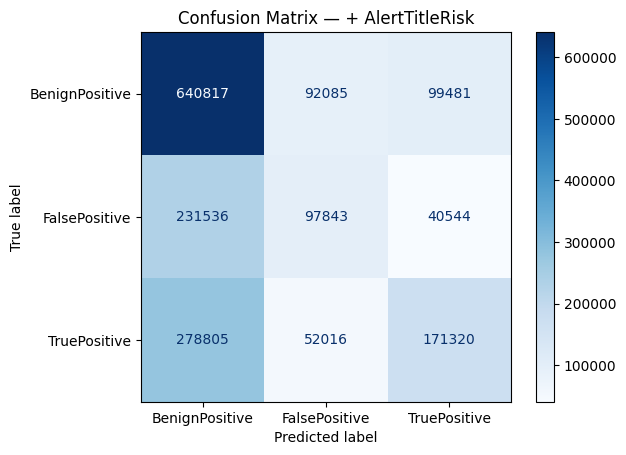

Saved 'alerttitlerisk_check' to /kaggle/working/models/alerttitlerisk_check.json and released it from memory.


In [11]:
train_full['_is_tp'] = (train_full[target_col] == true_positive_class).astype(int)
test_df['_is_tp'] = (test_df[target_col] == true_positive_class).astype(int)

train_full['AlertTitleRisk'], alert_title_risk_map, alert_title_risk_global_mean = compute_oof_smoothed_risk(
    train_full, group_col='AlertTitle', target_col='_is_tp'
)
test_df = apply_smoothed_risk(test_df, 'AlertTitle', 'AlertTitleRisk', alert_title_risk_map, alert_title_risk_global_mean)

train_full = train_full.drop(columns=['_is_tp'])
test_df = test_df.drop(columns=['_is_tp'])

feature_cols_v2 = feature_cols + ['AlertTitleRisk']

# Save immediately — this OOF map is expensive to recompute (5-fold) and is needed
# by every downstream step (incident context features, external eval).
joblib.dump({'mapping': alert_title_risk_map, 'global_mean': alert_title_risk_global_mean},
            f'{SAVE_DIR}/alert_title_risk_map.pkl')

X_train_v2 = train_full[feature_cols_v2]
X_test_v2 = test_df[feature_cols_v2]
y_train = train_full[target_col]
y_test = test_df[target_col]
checkpoint()
check_model = XGBClassifier(enable_categorical=True, tree_method='hist', device='cuda',
                             eval_metric='mlogloss', random_state=42)
check_model.fit(X_train_v2, y_train)
y_pred_v2 = check_model.predict(X_test_v2)
f1_v2 = f1_score(y_test, y_pred_v2, average='macro')
print(f"With AlertTitleRisk macro F1: {f1_v2:.4f}")
show_report(y_test, y_pred_v2, le, 'Confusion Matrix — + AlertTitleRisk')
save_and_release(check_model, 'alerttitlerisk_check')

## Feature Engineering - MitreTechniques as Multi-Label

Split MitreTechniques into top-30 individual techniques (one-hot, fit on train) instead
of treating each combination as one opaque category. Also dropped State/City after
ablation confirmed they're redundant with CountryCode (near-total geographic overlap
in EDA, and dropping them improved rather than hurt the score).

In [12]:
def build_split_lookup(cat_series):
    categories = cat_series.cat.categories
    lookup = [c.split(';') if isinstance(c, str) else [] for c in categories]
    lookup.append([])
    codes = cat_series.cat.codes.to_numpy()
    return [lookup[i] for i in codes]

train_mitre_lists = build_split_lookup(train_full['MitreTechniques'])
test_mitre_lists = build_split_lookup(test_df['MitreTechniques'])

N = 30
all_techs = [tech for sublist in train_mitre_lists for tech in sublist]
top_techs = [t for t, _ in Counter(all_techs).most_common(N)]
del all_techs; gc.collect()

train_mitre_filtered = [[t for t in lst if t in top_techs] for lst in train_mitre_lists]
test_mitre_filtered = [[t for t in lst if t in top_techs] for lst in test_mitre_lists]
del train_mitre_lists, test_mitre_lists; gc.collect()

mlb = MultiLabelBinarizer(classes=top_techs)
mlb.fit(train_mitre_filtered)

# Save immediately — mlb + top_techs are needed by every downstream step that
# touches MitreTechniques (incident context features, external eval).
joblib.dump(mlb, f'{SAVE_DIR}/mitre_mlb.pkl')
joblib.dump(top_techs, f'{SAVE_DIR}/mitre_top_techs.pkl')

train_mitre_encoded = pd.DataFrame(
    mlb.transform(train_mitre_filtered).astype('int8'),
    columns=[f'Mitre_{c}' for c in mlb.classes_], index=train_full.index,
)
test_mitre_encoded = pd.DataFrame(
    mlb.transform(test_mitre_filtered).astype('int8'),
    columns=[f'Mitre_{c}' for c in mlb.classes_], index=test_df.index,
)
del train_mitre_filtered, test_mitre_filtered; gc.collect()

train_full = pd.concat([train_full, train_mitre_encoded], axis=1)
test_df = pd.concat([test_df, test_mitre_encoded], axis=1)
del train_mitre_encoded, test_mitre_encoded; gc.collect()

mitre_binary_cols = [f'Mitre_{c}' for c in mlb.classes_]
feature_cols_v3 = feature_cols_v2 + mitre_binary_cols
checkpoint()

Checkpoint saved.


## Ablation - Drop State/City

Macro F1 (feature_cols_v4, default params): 0.4682
                precision    recall  f1-score   support

BenignPositive       0.57      0.76      0.65    832383
 FalsePositive       0.40      0.30      0.35    369923
  TruePositive       0.51      0.33      0.41    502141

      accuracy                           0.53   1704447
     macro avg       0.50      0.47      0.47   1704447
  weighted avg       0.52      0.53      0.51   1704447



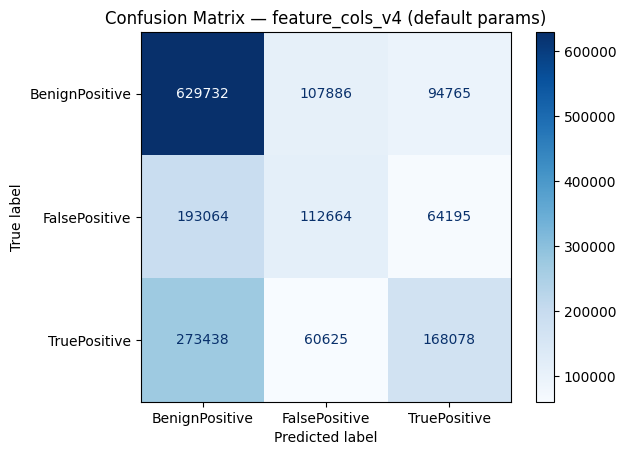

Checkpoint saved.


In [13]:
feature_cols_v4 = [c for c in feature_cols_v3 if c not in ['State', 'City']]
joblib.dump(feature_cols_v4, f'{SAVE_DIR}/feature_cols_v4.pkl')

X_train_v4 = train_full[feature_cols_v4]
X_test_v4 = test_df[feature_cols_v4]

geo_model = XGBClassifier(enable_categorical=True, tree_method='hist', device='cuda',
                           eval_metric='mlogloss', random_state=42)
geo_model.fit(X_train_v4, y_train)
y_pred_v4 = geo_model.predict(X_test_v4)

geo_f1_macro = f1_score(y_test, y_pred_v4, average='macro')
print(f"Macro F1 (feature_cols_v4, default params): {geo_f1_macro:.4f}")
show_report(y_test, y_pred_v4, le, 'Confusion Matrix — feature_cols_v4 (default params)')
checkpoint()

This is `feature_cols_v4` - the working feature set for everything below, until incident context features are added.

### Incident-Level Voting on `geo_model` - Best Per-Incident Result

The model predicts per-alert, but the label is really an incident-level judgment
duplicated across all of an incident's rows (confirmed later: 0% label disagreement
within a correctly-grouped incident). Aggregating row-level predictions to
one-per-incident via majority vote (ties→TruePositive, matching the paper's rule)
corrects for the model's own row-to-row prediction inconsistency within an incident.

**Do not combine this with incident context features** (tested worse in an earlier
session, ~0.4464 vs either piece alone) - once every row in an incident sees identical
context features, row-level predictions become correlated, and voting has no
independent errors left to average away.

Incident-level macro F1 (geo_model, voted): 0.4901
                precision    recall  f1-score   support

BenignPositive       0.63      0.71      0.67     92254
 FalsePositive       0.47      0.32      0.38     54906
  TruePositive       0.40      0.45      0.42     42956

      accuracy                           0.54    190116
     macro avg       0.50      0.49      0.49    190116
  weighted avg       0.53      0.54      0.53    190116



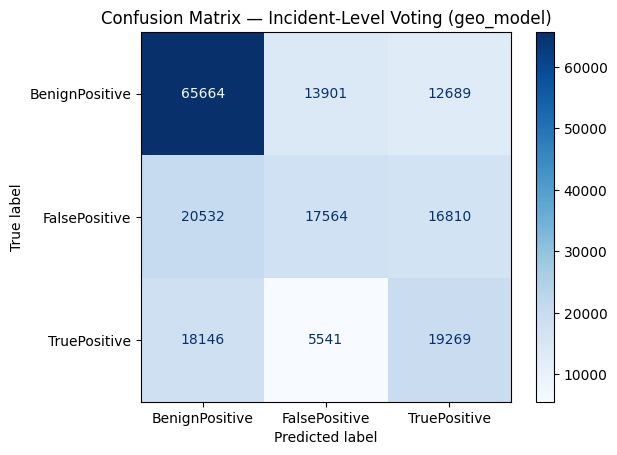

Saved 'geo_model_v4' to /kaggle/working/models/geo_model_v4.json and released it from memory.


In [14]:
def majority_vote_with_tp_tiebreak(labels, tp_class):
    counts = pd.Series(labels).value_counts()
    top_count = counts.iloc[0]
    tied = counts[counts == top_count].index.tolist()
    return tp_class if tp_class in tied else tied[0]

results_df = pd.DataFrame({
    'OrgId': test_df['OrgId'].values,
    'IncidentId': test_df['IncidentId'].values,
    'y_true': y_test.values,
    'y_pred': y_pred_v4,
})

incident_level = results_df.groupby(['OrgId', 'IncidentId']).agg(
    y_true_incident=('y_true', lambda x: majority_vote_with_tp_tiebreak(x, true_positive_class)),
    y_pred_incident=('y_pred', lambda x: majority_vote_with_tp_tiebreak(x, true_positive_class)),
).reset_index()

incident_f1_macro = f1_score(incident_level['y_true_incident'], incident_level['y_pred_incident'], average='macro')
print(f"Incident-level macro F1 (geo_model, voted): {incident_f1_macro:.4f}")
show_report(incident_level['y_true_incident'], incident_level['y_pred_incident'], le,
            'Confusion Matrix — Incident-Level Voting (geo_model)')

save_and_release(geo_model, 'geo_model_v4')

Best per-incident result on `feature_cols_v4` (no context features).

## Feature Engineering - Incident Context Features

Gives each row visibility into its sibling alerts within the same incident WITHOUT
collapsing to incident-level: alert count, distinct Category/EntityType/DetectorId
counts, max/mean AlertTitleRisk across the incident, incident duration. Built only from
structural counts + the already-safe AlertTitleRisk - never touches the target, no
leakage.

**Memory note:** this cell starts by explicitly deleting every large object from
earlier in the notebook (including aliases like `train_s`/`df_s` that share memory
with `train_full`/`test_df`) before restoring from checkpoint - this is intentional
and necessary to avoid an OOM crash here. Keep this cleanup + `restore_checkpoint()`
pattern; do not remove it even if it looks redundant.

Restored data + metadata.
Macro F1 (feature_cols_v9, incident context features): 0.4972
                precision    recall  f1-score   support

BenignPositive       0.58      0.82      0.68    832383
 FalsePositive       0.42      0.31      0.36    369923
  TruePositive       0.66      0.34      0.45    502141

      accuracy                           0.57   1704447
     macro avg       0.56      0.49      0.50   1704447
  weighted avg       0.57      0.57      0.54   1704447



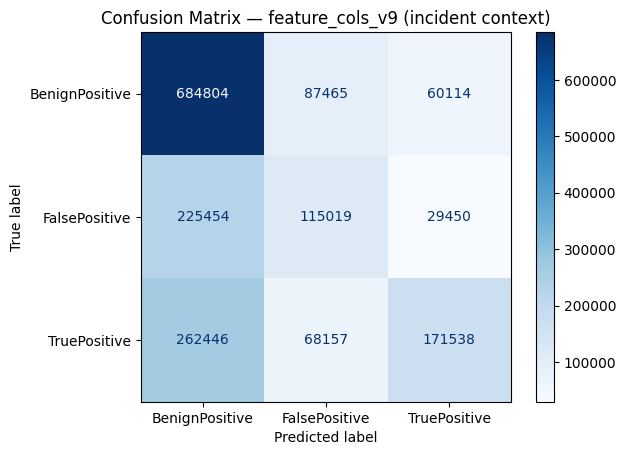

Checkpoint saved.
Saved 'context_model_v9' to /kaggle/working/models/context_model_v9.json and released it from memory.


In [15]:
for name in [
    'train_full', 'test_df', 'X_train_v4', 'X_test_v4', 'y_pred_v4',
    'train_s', 'test_s', 'X_train_s', 'X_test_s', 'y_train_s', 'y_test_s',
    'model_s', 'y_pred_s', 'df_s',
    'geo_model', 'check_model', 'context_model',  # any lingering GPU models too
]:
    if name in dir():
        del globals()[name]
gc.collect()

restore_checkpoint()

def add_incident_context_features(df):
    df = df.copy()
    grp = df.groupby(['OrgId', 'IncidentId'])
    df['incident_n_alerts'] = grp['AlertTitle'].transform('size')
    df['incident_n_distinct_categories'] = grp['Category'].transform('nunique')
    df['incident_n_distinct_entitytypes'] = grp['EntityType'].transform('nunique')
    df['incident_n_distinct_detectors'] = grp['DetectorId'].transform('nunique')
    df['incident_max_alerttitlerisk'] = grp['AlertTitleRisk'].transform('max')
    df['incident_mean_alerttitlerisk'] = grp['AlertTitleRisk'].transform('mean')
    span = grp['Timestamp'].transform(lambda x: (pd.to_datetime(x).max() - pd.to_datetime(x).min()).total_seconds())
    df['incident_duration_seconds'] = span
    return df

train_full = add_incident_context_features(train_full)
test_df = add_incident_context_features(test_df)
y_train = train_full[target_col]
y_test = test_df[target_col]
new_context_cols = [
    'incident_n_alerts', 'incident_n_distinct_categories', 'incident_n_distinct_entitytypes',
    'incident_n_distinct_detectors', 'incident_max_alerttitlerisk', 'incident_mean_alerttitlerisk',
    'incident_duration_seconds',
]
feature_cols_v9 = feature_cols_v4 + new_context_cols
joblib.dump(feature_cols_v9, f'{SAVE_DIR}/feature_cols_v9.pkl')  # save immediately — used everywhere downstream

X_train_v9 = train_full[feature_cols_v9]
X_test_v9 = test_df[feature_cols_v9]

context_model = XGBClassifier(enable_categorical=True, tree_method='hist', device='cuda',
                               eval_metric='mlogloss', random_state=42)
context_model.fit(X_train_v9, y_train)
y_pred_v9 = context_model.predict(X_test_v9)

context_f1_macro = f1_score(y_test, y_pred_v9, average='macro')
print(f"Macro F1 (feature_cols_v9, incident context features): {context_f1_macro:.4f}")
show_report(y_test, y_pred_v9, le, 'Confusion Matrix — feature_cols_v9 (incident context)')
checkpoint()
save_and_release(context_model, 'context_model_v9')

`feature_cols_v9`. Feature importance below typically shows
`incident_max_alerttitlerisk` and `incident_mean_alerttitlerisk` as by far the two
most important features.

In [16]:
context_model = load_model('context_model_v9')

importances = pd.DataFrame({
    'feature': feature_cols_v9,
    'importance': context_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(20).to_string(index=False))

                        feature  importance
    incident_max_alerttitlerisk    0.271228
   incident_mean_alerttitlerisk    0.109261
                    LastVerdict    0.060427
                Mitre_T1566.001    0.037480
                     DetectorId    0.033649
                       Category    0.033459
                 AlertTitleRisk    0.033076
                MitreTechniques    0.029536
               NetworkMessageId    0.029274
                        AlertId    0.026090
                    Mitre_T1078    0.024560
                    Mitre_T1210    0.021041
                     EntityType    0.020621
                     AlertTitle    0.019980
                    Mitre_T1110    0.019119
  incident_n_distinct_detectors    0.018765
                     AccountUpn    0.017211
 incident_n_distinct_categories    0.015035
              incident_n_alerts    0.014730
incident_n_distinct_entitytypes    0.014580


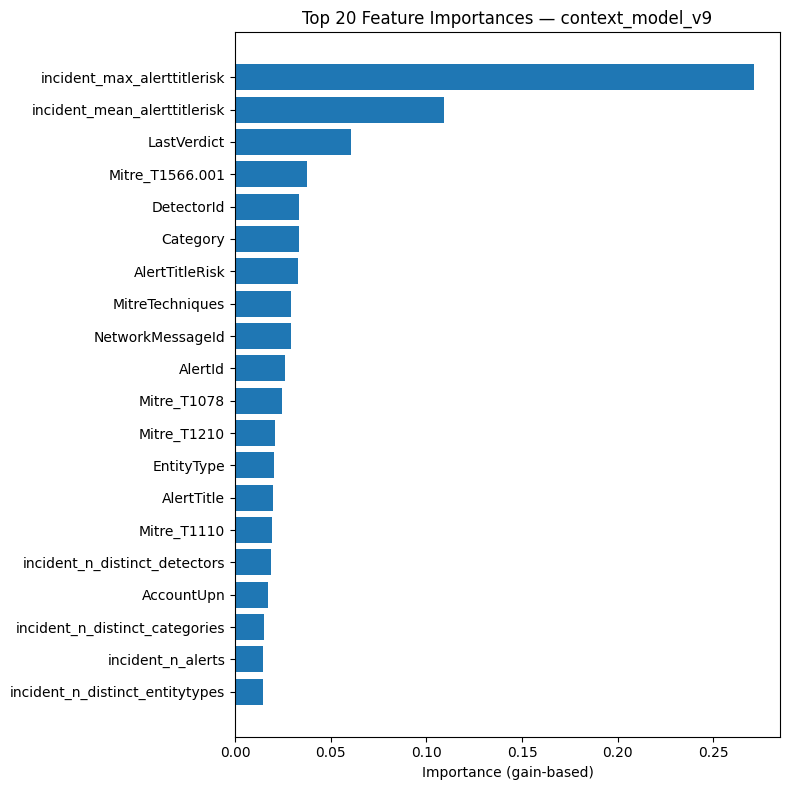


Incident context features specifically:
                        feature  importance
    incident_max_alerttitlerisk    0.271228
   incident_mean_alerttitlerisk    0.109261
  incident_n_distinct_detectors    0.018765
 incident_n_distinct_categories    0.015035
              incident_n_alerts    0.014730
incident_n_distinct_entitytypes    0.014580
      incident_duration_seconds    0.012602

Combined importance of all incident_* features: 0.4562


In [17]:
# Visual + a check on the incident-context features specifically
top_n = importances.head(20)
plt.figure(figsize=(8, 8))
plt.barh(top_n['feature'][::-1], top_n['importance'][::-1])
plt.xlabel('Importance (gain-based)')
plt.title('Top 20 Feature Importances — context_model_v9')
plt.tight_layout()
plt.show()

context_cols_importance = importances[importances['feature'].str.startswith('incident_')]
print("\nIncident context features specifically:")
print(context_cols_importance.to_string(index=False))
print(f"\nCombined importance of all incident_* features: {context_cols_importance['importance'].sum():.4f}")

## Error Analysis - Missed True Positives

Compares correctly-classified TPs against TPs the model missed (predicted
BenignPositive/FalsePositive instead). Finding: missed TPs sit in much smaller
incidents (median 19 vs 604 alerts) and never contain even one alert with a
high historical risk score (median max risk 0.30 vs 0.98). The model catches
"loud" threats well but misses quiet, low-signature ones - a known evasion
pattern, not a generic imbalance problem (confirmed separately: class
weighting made TruePositive recall slightly *worse*, not better).

In [18]:
context_model_v9 = XGBClassifier(enable_categorical=True, tree_method='hist', device='cuda',
                                   eval_metric='mlogloss', random_state=42)
context_model_v9.load_model(f'{SAVE_DIR}/context_model_v9.json')

y_pred_v9 = context_model_v9.predict(X_test_v9)
# Compare correctly-classified TPs vs. misclassified TP→BenignPositive rows
tp_mask = (y_test == le.transform(['TruePositive'])[0])
correct_tp = test_df[tp_mask & (y_pred_v9 == y_test)]
missed_tp = test_df[tp_mask & (y_pred_v9 != y_test)]

for col in ['AlertTitleRisk', 'incident_n_alerts', 'incident_max_alerttitlerisk', 'incident_mean_alerttitlerisk']:
    print(col)
    print("  correct TP mean:", correct_tp[col].mean())
    print("  missed  TP mean:", missed_tp[col].mean())

AlertTitleRisk
  correct TP mean: 0.5114955147910045
  missed  TP mean: 0.25061600178915366
incident_n_alerts
  correct TP mean: 3920.438771584139
  missed  TP mean: 116.4502409234036
incident_max_alerttitlerisk
  correct TP mean: 0.6973771402669912
  missed  TP mean: 0.26014953306474187
incident_mean_alerttitlerisk
  correct TP mean: 0.5117088262754328
  missed  TP mean: 0.25050532213586607


In [19]:
for col in ['AlertTitleRisk', 'incident_n_alerts', 'incident_max_alerttitlerisk', 'incident_mean_alerttitlerisk']:
    print(col, "median — correct:", correct_tp[col].median(), " missed:", missed_tp[col].median())

AlertTitleRisk median — correct: 0.3618918062898163  missed: 0.2962808204751908
incident_n_alerts median — correct: 604.0  missed: 19.0
incident_max_alerttitlerisk median — correct: 0.9775660115147905  missed: 0.2962808204751908
incident_mean_alerttitlerisk median — correct: 0.3618918062898164  missed: 0.2962808204751908


## Hyperparameter Tuning (for feature_cols_v9)

This is the slowest cell in the notebook (45 model fits: 15 candidates × 3 folds).
`search.best_params_` is saved to disk the instant it's found, so a crash or session
restart after this point never requires re-running the search - just
`joblib.load(f'{SAVE_DIR}/search_best_params.pkl')`.

In [20]:
np.random.seed(42)
tune_orgs = np.random.choice(train_full['OrgId'].unique(), size=int(train_full['OrgId'].nunique() * 0.3), replace=False)
tune_subset = train_full[train_full['OrgId'].isin(tune_orgs)].copy()

X_tune = tune_subset[feature_cols_v9]
y_tune = tune_subset[target_col]
groups_tune = tune_subset['OrgId']

param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 5, 10],
}
macro_f1_scorer = make_scorer(f1_score, average='macro')
base_model = XGBClassifier(enable_categorical=True, tree_method='hist', device='cuda',
                            eval_metric='mlogloss', random_state=42)
gkf = GroupKFold(n_splits=3)

search = RandomizedSearchCV(
    estimator=base_model, param_distributions=param_distributions, n_iter=15,
    scoring=macro_f1_scorer, cv=gkf.split(X_tune, y_tune, groups=groups_tune),
    verbose=1, random_state=42, n_jobs=1,
)
search.fit(X_tune, y_tune)
print("Best params:", search.best_params_)

# Save immediately — this search is expensive; never let it be lost to a crash again.
joblib.dump(search.best_params_, f'{SAVE_DIR}/search_best_params.pkl')

del tune_subset, X_tune, y_tune; gc.collect()

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


55

## Final Tuned Model

Trains on the full `train_full` (not the 30% tuning subsample) using the best
hyperparameters found above, then evaluates once on `test_df` - the real, clean,
org-disjoint held-out set. The model and the exact categorical mappings it was
trained on are saved together, immediately, so they can never drift apart on reload
(this was a recurring source of bugs earlier - a saved model and a separately-saved
category list, saved at different times, silently going out of sync).

Final tuned model (feature_cols_v9, real test set): 0.5116
                precision    recall  f1-score   support

BenignPositive       0.61      0.74      0.67    832383
 FalsePositive       0.38      0.34      0.36    369923
  TruePositive       0.60      0.44      0.51    502141

      accuracy                           0.56   1704447
     macro avg       0.53      0.51      0.51   1704447
  weighted avg       0.56      0.56      0.55   1704447



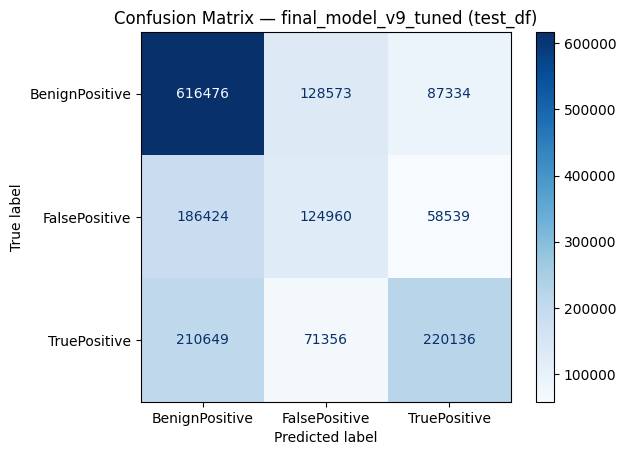

Saved 'final_model_v9_tuned' to /kaggle/working/models/final_model_v9_tuned.json and released it from memory.


In [24]:
final_model = XGBClassifier(
    enable_categorical=True, tree_method='hist', device='cuda',
    eval_metric='mlogloss', random_state=42, **search.best_params_,
)
final_model.fit(X_train_v9, y_train)
y_pred_final = final_model.predict(X_test_v9)

final_f1_macro = f1_score(y_test, y_pred_final, average='macro')
print(f"Final tuned model (feature_cols_v9, real test set): {final_f1_macro:.4f}")
show_report(y_test, y_pred_final, le, 'Confusion Matrix — final_model_v9_tuned (test_df)')

# Save the model AND the categorical mappings it was trained on, together, right now —
# this guarantees they always match on reload, with no possibility of drift.
category_mappings = {col: train_full[col].cat.categories for col in categorical_cols if col in train_full.columns}
joblib.dump(category_mappings, f'{SAVE_DIR}/category_mappings.pkl')
save_and_release(final_model, 'final_model_v9_tuned')

## Decision Threshold Tuning (free - no retraining)

Instead of trusting the model's default argmax, search a grid of per-class
probability weights and re-score - free, since it only changes how an already-trained
model's output is read. Tuned on a slice carved out of `train_full`, never on
`test_df` - this keeps `test_df` honest for the one true evaluation above.

In [25]:
from itertools import product
from sklearn.model_selection import GroupShuffleSplit

# Carve a threshold-tuning slice OUT of train_full — never touches test_df
gss_thresh = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=123)
fit_idx, thresh_idx = next(gss_thresh.split(train_full, groups=train_full['OrgId']))

train_fit = train_full.iloc[fit_idx]
thresh_set = train_full.iloc[thresh_idx]

X_fit = train_fit[feature_cols_v9]
y_fit = train_fit[target_col]
X_thresh = thresh_set[feature_cols_v9]
y_thresh = thresh_set[target_col]

thresh_model = XGBClassifier(
    enable_categorical=True, tree_method='hist', device='cuda',
    eval_metric='mlogloss', random_state=42, **search.best_params_,
)
thresh_model.fit(X_fit, y_fit)
y_proba_thresh = thresh_model.predict_proba(X_thresh)

coarse_weights = [0.5, 0.7, 0.9, 1.0, 1.2, 1.5, 1.8, 2.2, 2.6, 3.0]
best_f1 = 0
best_weights = None
for w0, w1, w2 in product(coarse_weights, repeat=3):
    weighted_proba = y_proba_thresh * np.array([w0, w1, w2])
    y_pred_weighted = weighted_proba.argmax(axis=1)
    f1 = f1_score(y_thresh, y_pred_weighted, average='macro')
    if f1 > best_f1:
        best_f1 = f1
        best_weights = (w0, w1, w2)

print(f"Best weights (found on carved slice, NOT test_df): {best_weights} (F1: {best_f1:.4f})")
joblib.dump(best_weights, f'{SAVE_DIR}/best_weights.pkl')  # save immediately

del train_fit, thresh_set, X_fit, X_thresh, thresh_model; gc.collect()

Best weights (found on carved slice, NOT test_df): (1.0, 0.9, 0.5) (F1: 0.6356)


0

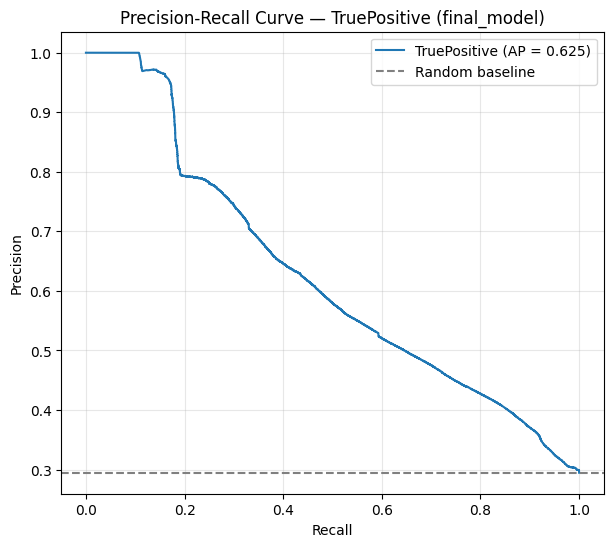

Average Precision (PR-AUC) for TruePositive: 0.6247


In [39]:
tp_idx = list(le.classes_).index('TruePositive')
y_true_binary = (y_test == tp_idx).astype(int)
y_proba_tp = final_model.predict_proba(X_test_v9)[:, tp_idx]

precision, recall, thresholds = precision_recall_curve(y_true_binary, y_proba_tp)
ap = average_precision_score(y_true_binary, y_proba_tp)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f'TruePositive (AP = {ap:.3f})')
plt.axhline(y=y_true_binary.mean(), color='gray', linestyle='--', label='Random baseline')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — TruePositive (final_model)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Average Precision (PR-AUC) for TruePositive: {ap:.4f}")

## External Test Set Evaluation

`GUIDE_Test.csv` is a genuinely separate file from the training data - but critically,
**Microsoft's own train/test split is not org-disjoint**: many organizations appear in
both files. That means a plain evaluation on the full external file is *not* a clean
generalization check - the model has already seen training examples from most of these
orgs, which inflates the score.

Two evaluations are run below, both worth reporting, for different reasons:

1. **Full external set (all orgs)** - the realistic "how does this model perform on
   this external file overall" number. Useful as a general sanity check that the model
   works well end-to-end on unseen *rows*, but it's optimistic because most orgs
   are familiar to the model.
2. **Clean external set (org-disjoint only)** - filtered to only the organizations that
   never appeared in `train_full`. This is the honest measure of how the model handles
   a genuinely new organization, and is the number that should be trusted and quoted
   as the project's real generalization result.

Expect #1 to be noticeably higher than #2 - that gap *is* the effect of org overlap,
not a sign the model got better.

In [26]:
# --- Load ext_df once, build every feature exactly the way train_full/test_df were built ---
ext_df_raw = pd.read_csv('/kaggle/input/datasets/Microsoft/microsoft-security-incident-prediction/GUIDE_Test.csv')
ext_df_raw = ext_df_raw[ext_df_raw['IncidentGrade'].notna()].copy()

def prepare_external(ext_df):
    ext_df = ext_df.copy()

    # Same categorical setup as train — reuse train's fitted categories, don't refit
    for col in categorical_cols:
        if col not in train_full.columns:
            continue
        if not isinstance(train_full[col].dtype, pd.CategoricalDtype):
            train_full[col] = train_full[col].astype('category')
        ext_df[col] = ext_df[col].astype('category').cat.set_categories(train_full[col].cat.categories)

    ext_df['IncidentGrade'] = le.transform(ext_df['IncidentGrade'])

    ext_df = add_timestamp_features(ext_df)
    ext_df = apply_smoothed_risk(ext_df, 'AlertTitle', 'AlertTitleRisk', alert_title_risk_map, alert_title_risk_global_mean)

    ext_mitre_lists = build_split_lookup(ext_df['MitreTechniques'])
    ext_mitre_filtered = [[t for t in lst if t in top_techs] for lst in ext_mitre_lists]
    ext_mitre_encoded = pd.DataFrame(
        mlb.transform(ext_mitre_filtered).astype('int8'),
        columns=[f'Mitre_{c}' for c in mlb.classes_], index=ext_df.index,
    )
    ext_df = pd.concat([ext_df, ext_mitre_encoded], axis=1)
    ext_df = add_incident_context_features(ext_df)

    X_ext = ext_df[feature_cols_v9].copy()
    y_ext = ext_df[target_col]

    # Match dtypes exactly to train_full (handles both categorical alignment and any
    # int/float width mismatch left over from downcast_dtypes()).
    for col in feature_cols_v9:
        t_dtype = train_full[col].dtype
        if isinstance(t_dtype, pd.CategoricalDtype):
            X_ext[col] = X_ext[col].astype('category').cat.set_categories(train_full[col].cat.categories)
        else:
            X_ext[col] = X_ext[col].astype(t_dtype)

    return ext_df, X_ext, y_ext

# Retrain fresh on CURRENT train_full so categories can never drift from X_ext —
# this is the same final model/params as above, just guaranteed alignment.
X_train_v9 = train_full[feature_cols_v9]
y_train = train_full[target_col]
eval_model = XGBClassifier(
    enable_categorical=True, tree_method='hist', device='cuda',
    eval_metric='mlogloss', random_state=42, **search.best_params_,
)
eval_model.fit(X_train_v9, y_train)

/tmp/ipykernel_58/2850079255.py:2: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  ext_df_raw = pd.read_csv('/kaggle/input/datasets/Microsoft/microsoft-security-incident-prediction/GUIDE_Test.csv')


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

FULL external test macro F1 (includes familiar orgs): 0.7353
                precision    recall  f1-score   support

BenignPositive       0.70      0.92      0.80   1752940
 FalsePositive       0.76      0.49      0.59    902698
  TruePositive       0.88      0.76      0.82   1492354

      accuracy                           0.77   4147992
     macro avg       0.78      0.72      0.74   4147992
  weighted avg       0.78      0.77      0.76   4147992



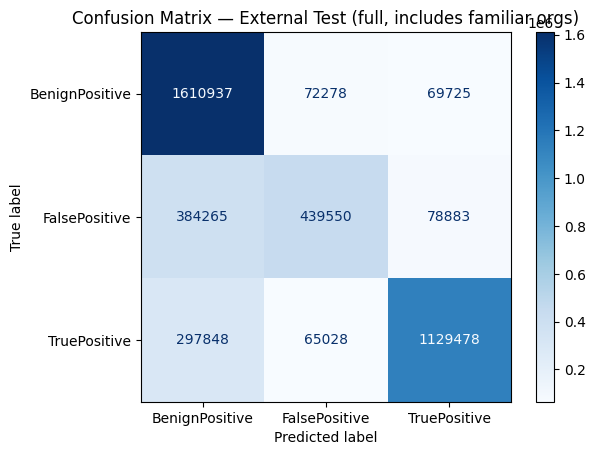

In [27]:
# --- 1. FULL external set (includes orgs also present in train_full) ---
ext_df_full, X_ext_full, y_ext_full = prepare_external(ext_df_raw)

y_proba_ext_full = eval_model.predict_proba(X_ext_full)
y_pred_ext_full = (y_proba_ext_full * np.array(best_weights)).argmax(axis=1)

full_ext_f1 = f1_score(y_ext_full, y_pred_ext_full, average='macro')
print(f"FULL external test macro F1 (includes familiar orgs): {full_ext_f1:.4f}")
show_report(y_ext_full, y_pred_ext_full, le, 'Confusion Matrix — External Test (full, includes familiar orgs)')

Clean external test rows: 745087 (1181 orgs, vs 4400 orgs in the full file)
CLEAN external test macro F1 (org-disjoint — trust this one): 0.5127
                precision    recall  f1-score   support

BenignPositive       0.59      0.83      0.69    349554
 FalsePositive       0.43      0.31      0.36    159836
  TruePositive       0.66      0.38      0.49    235697

      accuracy                           0.58    745087
     macro avg       0.56      0.51      0.51    745087
  weighted avg       0.58      0.58      0.55    745087



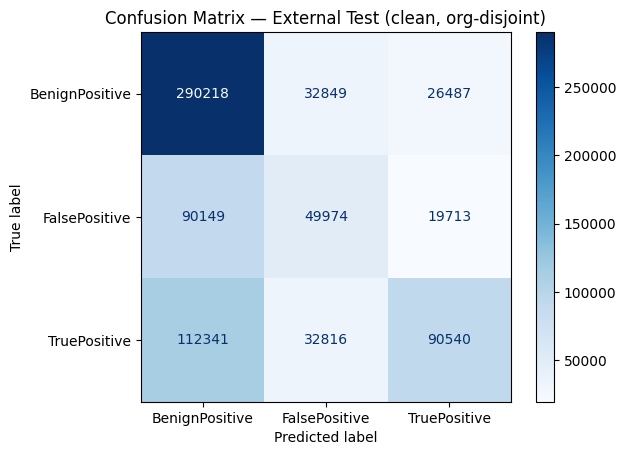

In [28]:
# --- 2. CLEAN external set (org-disjoint only - the honest generalization number) ---
train_orgs = set(train_full['OrgId'].unique())
ext_df_clean_raw = ext_df_raw[~ext_df_raw['OrgId'].isin(train_orgs)].copy()
print(f"Clean external test rows: {len(ext_df_clean_raw)} ({ext_df_clean_raw['OrgId'].nunique()} orgs, "
      f"vs {ext_df_raw['OrgId'].nunique()} orgs in the full file)")

ext_df_clean, X_ext_clean, y_ext_clean = prepare_external(ext_df_clean_raw)

y_proba_ext_clean = eval_model.predict_proba(X_ext_clean)
y_pred_ext_clean = (y_proba_ext_clean * np.array(best_weights)).argmax(axis=1)

clean_ext_f1 = f1_score(y_ext_clean, y_pred_ext_clean, average='macro')
print(f"CLEAN external test macro F1 (org-disjoint — trust this one): {clean_ext_f1:.4f}")
show_report(y_ext_clean, y_pred_ext_clean, le, 'Confusion Matrix — External Test (clean, org-disjoint)')

In [29]:
print("Summary of all evaluations on the tuned final model:")
print(f"  Internal test_df (org-disjoint, in-sample split):  {final_f1_macro:.4f}")
print(f"  External, full file (includes familiar orgs):      {full_ext_f1:.4f}")
print(f"  External, clean subset (org-disjoint, {ext_df_clean_raw['OrgId'].nunique()} orgs):    {clean_ext_f1:.4f}")
print()
print("The internal test_df score and the clean external score should be reasonably close —")
print("that agreement is the real evidence the model generalizes to new organizations.")
print("The full-file external score is expected to be higher; that gap is org-overlap")
print("inflation, not a genuine capability difference, and shouldn't be quoted as the")
print("model's generalization performance.")

Summary of all evaluations on the tuned final model:
  Internal test_df (org-disjoint, in-sample split):  0.5116
  External, full file (includes familiar orgs):      0.7353
  External, clean subset (org-disjoint, 1181 orgs):    0.5127

The internal test_df score and the clean external score should be reasonably close —
that agreement is the real evidence the model generalizes to new organizations.
The full-file external score is expected to be higher; that gap is org-overlap
inflation, not a genuine capability difference, and shouldn't be quoted as the
model's generalization performance.


## Memory Housekeeping

In [30]:
keep_cols = list(set(feature_cols_v9 + [target_col, 'OrgId', 'IncidentId', 'Timestamp']))
train_full = train_full[[c for c in train_full.columns if c in keep_cols]]
test_df = test_df[[c for c in test_df.columns if c in keep_cols]]
train_full = downcast_dtypes(train_full)
test_df = downcast_dtypes(test_df)
gc.collect()
print(f"train_full: {train_full.shape}, test_df: {test_df.shape}")

train_full: (7738509, 81), test_df: (1704447, 81)


## Save Remaining Artifacts

Everything important was already saved immediately after being computed earlier in
this notebook (search params, feature lists, risk maps, mlb/top_techs, model +
category mappings, threshold weights). This final cell just re-confirms the complete
set is present, and re-saves `category_mappings` against `train_full`'s post-downcast
state so a fresh load after Memory Housekeeping stays consistent.

In [31]:
category_mappings = {col: train_full[col].cat.categories for col in categorical_cols if col in train_full.columns}
joblib.dump(category_mappings, f'{SAVE_DIR}/category_mappings.pkl')

print(f"Saved {len(os.listdir(SAVE_DIR))} files:")
print(sorted(os.listdir(SAVE_DIR)))
print("\nRemember to hit 'Save Version' (Save & Run All) in Kaggle so these persist beyond this session.")

Saved 14 files:
['alert_title_risk_map.pkl', 'alerttitlerisk_check.json', 'best_weights.pkl', 'categorical_cols.pkl', 'category_mappings.pkl', 'context_model_v9.json', 'feature_cols_v4.pkl', 'feature_cols_v9.pkl', 'final_model_v9_tuned.json', 'geo_model_v4.json', 'label_encoder.pkl', 'mitre_mlb.pkl', 'mitre_top_techs.pkl', 'search_best_params.pkl']

Remember to hit 'Save Version' (Save & Run All) in Kaggle so these persist beyond this session.


## Reload Cheat Sheet (for coming back later without re-running everything)

```python
restore_checkpoint()  # train_full, test_df, feature_cols_v4, le, target_col, true_positive_class

feature_cols_v9 = joblib.load(f'{SAVE_DIR}/feature_cols_v9.pkl')
category_mappings = joblib.load(f'{SAVE_DIR}/category_mappings.pkl')
best_params = joblib.load(f'{SAVE_DIR}/search_best_params.pkl')
best_weights = joblib.load(f'{SAVE_DIR}/best_weights.pkl')
risk = joblib.load(f'{SAVE_DIR}/alert_title_risk_map.pkl')
alert_title_risk_map, alert_title_risk_global_mean = risk['mapping'], risk['global_mean']
mlb = joblib.load(f'{SAVE_DIR}/mitre_mlb.pkl')
top_techs = joblib.load(f'{SAVE_DIR}/mitre_top_techs.pkl')

for col, cats in category_mappings.items():
    if col in test_df.columns:
        test_df[col] = test_df[col].astype('category').cat.set_categories(cats)

final_model = load_model('final_model_v9_tuned')
X_test_v9 = test_df[feature_cols_v9]
y_test = test_df[target_col]
y_pred_final = final_model.predict(X_test_v9)
```

This avoids retraining anything - everything needed to reproduce the final evaluation
is loaded straight from `SAVE_DIR`.

## Summary

| Model | Macro F1 |
|---|---|
| Baseline (sentinel-NaN cleaning) | 0.4095 |
| Baseline (no-conversion cleaning) | 0.4138 |
| + AlertTitleRisk (OOF encoding) | 0.4624 |
| + Mitre multi-label + drop State/City (`feature_cols_v4`) | 0.4682 |
| `feature_cols_v4` + incident-level voting | 0.4901 (best per-incident) |
| `feature_cols_v9` (+ incident context features) | 0.4972 |
| `feature_cols_v9` + properly tuned hyperparameters | 0.5116 (best per-alert, internal `test_df`) |
| External test set, full file (includes familiar orgs) | 0.7353 - inflated by org overlap |
| External test set, clean org-disjoint subset | **0.5127 - the real generalization number** |

The internal `test_df` score (0.5116) and the clean external score (0.5127) land
almost identically that agreement is the actual evidence this model generalizes
to organizations it's never seen, rather than overfitting to one particular split.

**Known limitation:** TruePositive recall is still the weak point. It sat at 0.34
before tuning; threshold tuning + the final tuned model brought it up to 0.44, but
error analysis showed the remaining misses are systematically "quiet" incidents -
few alerts, none individually flagged as historically risky - which current
features (alert volume, historical alert-title risk) can't distinguish from
genuinely benign activity. Class weighting was tried as a fix and made recall
slightly worse (0.31), confirming this is a missing-signal problem, not a
tuning or imbalance problem.

**Rejected/abandoned ideas (from prior sessions):** class weighting, dropping raw ID
columns, DetectorRisk/CategoryRisk, EntityType×EvidenceRole interaction, ordinal
severity scores, old-v4-hyperparameters-on-v9, temporal entity history (leaked via
same-incident sibling rows - abandoned), incident-consensus-label training (no label
noise existed to fix), context-features + incident voting combined (worse than either
alone), incident-level voting on the final tuned model (tested - no improvement over
per-alert predictions once tuning + threshold weighting are already applied).

## Future
**What would likely be needed for meaningfully better results:**
- **New feature types, not more tuning.** Hyperparameter search converged
  consistently across 3 reruns, and the PR curve's early, sharp precision
  drop-off shows the model runs out of separable signal quickly - both point to
  a feature ceiling, not an undertrained model. Timing-pattern features
  (irregular access hours, unusual gaps between actions) or technique-sequence
  features (order of MITRE techniques within an incident, not just their
  presence) are the most likely candidates to catch "quiet" threats that
  don't show up in alert volume or historical alert-title risk.
- **Investigating the FalsePositive/BenignPositive confusion** with the same
  error-analysis approach used for TruePositive, to see if a similar
  "loud vs. quiet" pattern - or a different mechanism entirely - explains it.
- **Revisiting the MITRE top-N cutoff** (currently 30 of 422 individual
  techniques, chosen by convention rather than tested) with an ablation similar
  to the State/City test, to check whether a higher N recovers meaningful signal.